# Mixture of Experts (MoE) aplicado a CIFAR-10 — versión corregida
**Estudiante:** Felix Maturano Zarate  
**Materia:** Inteligencia Artificial (SIS421)  
**Fecha:** 2026

En este notebook implementamos un **Vision Transformer con Mixture of Experts**: la imagen se corta en *patches* (igual que en `03_multihead_attention.ipynb`), la **atención multi-cabeza** deja que los patches se miren entre sí y la capa **feed-forward** de cada bloque se reemplaza por un **MoE con Noisy Top-K Gating**. Lo comparamos contra el mismo Transformer con feed-forward denso.

$$MultiHead(Q,K,V) = Concat(head_1, ..., head_h)W^O \qquad y = \sum_{i \in TopK(x)} g_i(x)\, E_i(x)$$

In [4]:
import json
import os
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.metrics import confusion_matrix, classification_report

from moe import VisionMoE, MoE, count_params
from train_utils import get_loaders, fit, evaluate, CLASSES, MEAN, STD

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_theme(style='whitegrid')

# ---------------- Configuración ----------------
EPOCHS = 30
BATCH = 128
DIM, DEPTH, HEADS = 128, 6, 4
NUM_EXPERTS, TOP_K, EXPERT_HIDDEN = 8, 2, 256
RUN_DENSE = True          # False = entrena solo el MoE (más rápido)
print('Dispositivo:', device)


Dispositivo: cuda


## 2. Datos: de imagen a secuencia de patches

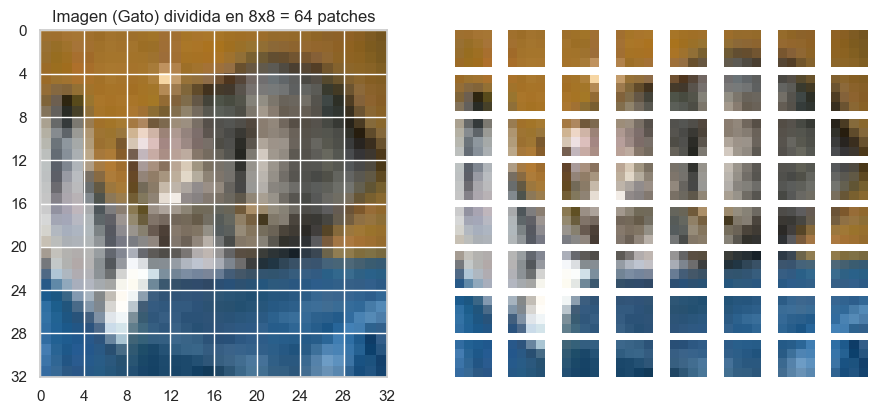

In [5]:
train_dl, test_dl = get_loaders(BATCH)

def denorm(x):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

imgs, labels = next(iter(test_dl))

# Una imagen y los 64 patches de 4x4 que verá el Transformer (como los 16 patches de 7x7 de MNIST)
fig = plt.figure(figsize=(11, 4.5))
ax = fig.add_subplot(1, 2, 1)
ax.imshow(denorm(imgs[0]), extent=(0, 32, 32, 0))
ax.set_xticks(range(0, 33, 4)); ax.set_yticks(range(0, 33, 4)); ax.grid(color='white', lw=1)
ax.set_title(f'Imagen ({CLASSES[labels[0]]}) dividida en 8x8 = 64 patches')
patches = imgs[0].unfold(1, 4, 4).unfold(2, 4, 4)       # [3, 8, 8, 4, 4]
for i in range(8):
    for j in range(8):
        a = fig.add_subplot(8, 16, i * 16 + 9 + j)
        a.imshow(denorm(patches[:, i, j])); a.axis('off')
plt.show()

## 3. Modelos: Transformer denso vs Transformer con MoE

El baseline denso usa un feed-forward de `k × expert_hidden` neuronas, es decir, **el mismo cómputo activo por token** que el MoE (que activa `k` expertos de `expert_hidden`). El MoE tiene más parámetros *totales* (capacidad) pero cada token solo usa `k` de `E` expertos.

In [6]:
cfg = dict(dim=DIM, depth=DEPTH, n_heads=HEADS, num_experts=NUM_EXPERTS, k=TOP_K, expert_hidden=EXPERT_HIDDEN)
moe_model = VisionMoE(use_moe=True, **cfg)
dense_model = VisionMoE(use_moe=False, **cfg)

rows = []
for name, m in [('Denso', dense_model), ('MoE', moe_model)]:
    total, active = count_params(m)
    rows.append({'Modelo': name, 'Parámetros totales': f'{total:,}', 'Parámetros activos por token': f'{active:,}'})
display(pd.DataFrame(rows))

# Comprobación de formas
logits, aux = moe_model(torch.randn(4, 3, 32, 32))
print('logits:', tuple(logits.shape), '| aux_loss (≈1.0 = reparto balanceado):', round(float(aux), 3))

,Modelo,Parámetros totales,Parámetros activos por token
0,Denso,"1,205,642","1,205,642"
1,MoE,"3,591,866","1,218,746"


logits: (4, 10) | aux_loss (≈1.0 = reparto balanceado): 1.01


## 4. Entrenamiento

In [ ]:
hist_dense = fit(dense_model, train_dl, test_dl, device, epochs=EPOCHS, name='Denso') if RUN_DENSE else None

[Denso] época 01/30 | train loss 1.908 acc 29.6% | val loss 1.792 acc 34.2% | aux 0.000 | 66s
[Denso] época 02/30 | train loss 1.657 acc 39.2% | val loss 1.664 acc 39.3% | aux 0.000 | 65s


In [ ]:
hist_moe = fit(moe_model, train_dl, test_dl, device, epochs=EPOCHS, name='MoE')

[MoE] época 01/30 | train loss 1.886 acc 30.1% | val loss 1.774 acc 34.6% | aux 1.019 | 96s
[MoE] época 02/30 | train loss 1.639 acc 40.2% | val loss 1.606 acc 41.7% | aux 1.017 | 85s
[MoE] época 03/30 | train loss 1.445 acc 48.4% | val loss 1.391 acc 49.7% | aux 1.027 | 80s
[MoE] época 04/30 | train loss 1.319 acc 53.2% | val loss 1.329 acc 52.8% | aux 1.035 | 81s


KeyboardInterrupt: 

In [ ]:
torch.save(moe_model.state_dict(), 'moe_cifar10.pt')
with open('historial.json', 'w') as f:
    json.dump({'moe': hist_moe, 'dense': hist_dense}, f)

## 5. Gráficas de entrenamiento
Qué buscar: (a) que las curvas de test suban y se estabilicen sin picos, (b) la brecha train–test del MoE (sobreajuste), (c) que la pérdida de balanceo se mantenga cerca de 1.0 (ningún experto "muerto" ni saturado).

In [ ]:
ep = np.arange(1, EPOCHS + 1)
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

ax[0, 0].plot(ep, np.array(hist_moe['val_acc']) * 100, 'o-', label='MoE', color='tab:blue')
if hist_dense: ax[0, 0].plot(ep, np.array(hist_dense['val_acc']) * 100, 's--', label='Denso', color='tab:orange')
ax[0, 0].set(title='Accuracy en test', xlabel='Época', ylabel='%'); ax[0, 0].legend()

ax[0, 1].plot(ep, hist_moe['val_loss'], 'o-', label='MoE', color='tab:blue')
if hist_dense: ax[0, 1].plot(ep, hist_dense['val_loss'], 's--', label='Denso', color='tab:orange')
ax[0, 1].set(title='Loss en test (cross-entropy)', xlabel='Época'); ax[0, 1].legend()

ax[1, 0].plot(ep, np.array(hist_moe['train_acc']) * 100, label='train', color='tab:green')
ax[1, 0].plot(ep, np.array(hist_moe['val_acc']) * 100, label='test', color='tab:blue')
ax[1, 0].set(title='MoE: train vs test (brecha = sobreajuste)', xlabel='Época', ylabel='%'); ax[1, 0].legend()

ax[1, 1].plot(ep, hist_moe['aux'], color='tab:red', label='balanceo de carga')
ax[1, 1].axhline(1.0, ls='--', color='gray', label='ideal (1.0)')
ax[1, 1].set(title='MoE: balanceo de carga y learning rate', xlabel='Época'); ax[1, 1].legend(loc='upper left')
ax2 = ax[1, 1].twinx(); ax2.plot(ep, hist_moe['lr'], color='tab:purple', alpha=.5); ax2.set_ylabel('lr'); ax2.grid(False)

plt.tight_layout(); plt.savefig('fig_curvas.png', dpi=150); plt.show()

## 6. Evaluación sobre el conjunto de prueba

In [ ]:
results = {}
for name, m in [('MoE', moe_model)] + ([('Denso', dense_model)] if RUN_DENSE else []):
    loss, acc, preds, labels_t, conf = evaluate(m, test_dl, device)
    results[name] = dict(loss=loss, acc=acc, preds=preds.numpy(), labels=labels_t.numpy(), conf=conf.numpy())
    print(f'{name}: accuracy test = {acc:.2%} | loss = {loss:.3f}')

print('\nReporte de clasificación (MoE):')
print(classification_report(results['MoE']['labels'], results['MoE']['preds'], target_names=CLASSES, digits=3))

In [ ]:
# Matriz de confusión normalizada por fila (cada fila suma 1 = recall por clase)
fig, axes = plt.subplots(1, len(results), figsize=(9 * len(results), 7.5), squeeze=False)
for ax, (name, r) in zip(axes[0], results.items()):
    cm = confusion_matrix(r['labels'], r['preds'], normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES,
                vmin=0, vmax=1, cbar=False, ax=ax)
    ax.set(title=f'Matriz de confusión — {name} ({r["acc"]:.1%})', xlabel='Clase predicha', ylabel='Clase real')
plt.tight_layout(); plt.savefig('fig_confusion.png', dpi=150); plt.show()

# Accuracy por clase: ¿en qué clases ayuda (o no) el MoE?
per_class = pd.DataFrame({n: confusion_matrix(r['labels'], r['preds'], normalize='true').diagonal() * 100
                          for n, r in results.items()}, index=CLASSES)
per_class.plot.bar(figsize=(11, 4), rot=0, ylabel='% acierto', title='Accuracy por clase')
plt.tight_layout(); plt.show()

## 7. ¿Qué hace el MoE por dentro?
Analizamos el enrutamiento sobre todo el conjunto de prueba: **a qué experto manda el router cada patch**.  
Nota: en modelos pequeños de visión los expertos suelen especializarse en rasgos locales (color, textura, borde, posición) más que en "una clase por experto"; no esperes un experto de gatos y otro de perros.

In [ ]:
@torch.no_grad()
def collect_routing(model, loader):
    # Para cada capa MoE: expertos elegidos por cada patch [N_imgs, 64, k], y las etiquetas
    model.eval()
    moes = [m for m in model.modules() if isinstance(m, MoE)]
    idx = [[] for _ in moes]
    labs = []
    for x, y in loader:
        model(x.to(device))
        for l, m in enumerate(moes):
            idx[l].append(m.last_top_idx.view(x.size(0), -1, m.router.k).cpu())
        labs.append(y)
    return [torch.cat(i) for i in idx], torch.cat(labs)

route_idx, route_labels = collect_routing(moe_model, test_dl)
E = NUM_EXPERTS

# --- Carga por experto y por capa ---
load = np.stack([torch.bincount(i.flatten(), minlength=E).float().div(i.numel()).numpy() for i in route_idx])
plt.figure(figsize=(9, 4.5))
sns.heatmap(load * 100, annot=True, fmt='.1f', cmap='viridis',
            xticklabels=[f'E{e}' for e in range(E)], yticklabels=[f'Capa {l + 1}' for l in range(DEPTH)],
            cbar_kws={'label': '% de asignaciones'})
plt.title(f'Uso de cada experto por capa (reparto ideal = {100 / E:.1f} %)')
plt.tight_layout(); plt.savefig('fig_carga_expertos.png', dpi=150); plt.show()
print(f'Experto más usado: {load.max():.1%} | menos usado: {load.min():.1%} (ideal {1 / E:.1%})')

In [ ]:
# --- Clase x Experto: ¿qué porcentaje de patches de cada clase va a cada experto? ---
def class_expert_matrix(idx, labels):
    M = torch.stack([torch.bincount(idx[labels == c].flatten(), minlength=E).float() for c in range(len(CLASSES))])
    return (M / M.sum(1, keepdim=True)).numpy() * 100

show_layers = [0, DEPTH // 2, DEPTH - 1]
fig, axes = plt.subplots(1, len(show_layers), figsize=(6 * len(show_layers), 5))
for ax, l in zip(axes, show_layers):
    sns.heatmap(class_expert_matrix(route_idx[l], route_labels), annot=True, fmt='.0f', cmap='magma_r',
                xticklabels=[f'E{e}' for e in range(E)], yticklabels=CLASSES, cbar=False, ax=ax)
    ax.set_title(f'Capa {l + 1}: % de patches de cada clase por experto')
plt.tight_layout(); plt.savefig('fig_clase_experto.png', dpi=150); plt.show()

In [ ]:
# --- Mapa espacial: qué experto (top-1) procesa cada patch de la imagen ---
colors = plt.cm.tab10.colors[:E]
cmap = ListedColormap(colors)
imgs_s, labs_s = next(iter(test_dl))          # test_dl no mezcla: coincide con route_idx[:, :BATCH]
n_show = 6
fig, axes = plt.subplots(n_show, 1 + len(show_layers), figsize=(3.2 * (1 + len(show_layers)), 3 * n_show))
for r in range(n_show):
    axes[r, 0].imshow(denorm(imgs_s[r])); axes[r, 0].set_title(CLASSES[labs_s[r]]); axes[r, 0].axis('off')
    for c, l in enumerate(show_layers):
        top1 = route_idx[l][r, :, 0].reshape(8, 8).numpy()
        axes[r, c + 1].imshow(denorm(imgs_s[r]), extent=(-0.5, 31.5, 31.5, -0.5))
        axes[r, c + 1].imshow(top1, cmap=cmap, vmin=-0.5, vmax=E - 0.5, alpha=0.6,
                              extent=(-0.5, 31.5, 31.5, -0.5), interpolation='nearest')
        axes[r, c + 1].axis('off')
        if r == 0: axes[r, c + 1].set_title(f'Capa {l + 1}')
fig.legend(handles=[Patch(color=colors[e], label=f'E{e}') for e in range(E)], loc='lower center', ncol=E)
plt.tight_layout(rect=(0, 0.03, 1, 1)); plt.savefig('fig_mapa_enrutamiento.png', dpi=150); plt.show()

## 8. Predicciones de ejemplo (verde = acierto, rojo = error)

In [ ]:
moe_model.eval()
x, y = next(iter(test_dl))
with torch.no_grad():
    logits, _ = moe_model(x.to(device))
conf, pred = logits.softmax(1).max(1)
conf, pred = conf.cpu(), pred.cpu()

fig = plt.figure(figsize=(12, 12))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    ax.imshow(denorm(x[i]))
    ok = pred[i] == y[i]
    ax.set_title(f'Real: {CLASSES[y[i]]}\nPred: {CLASSES[pred[i]]} ({conf[i]:.0%})', color='green' if ok else 'red')
    ax.axis('off')
plt.tight_layout(); plt.show()

## 9. Resumen final

In [ ]:
summary = []
for name, m, h in [('Denso', dense_model, hist_dense), ('MoE', moe_model, hist_moe)]:
    if h is None: continue
    total, active = count_params(m)
    summary.append({'Modelo': name, 'Params totales': f'{total:,}', 'Params activos/token': f'{active:,}',
                    'Accuracy final (test)': f"{h['val_acc'][-1]:.2%}", 'Mejor accuracy (test)': f"{max(h['val_acc']):.2%}",
                    'Accuracy train final': f"{h['train_acc'][-1]:.2%}", 'Seg/época': f"{np.mean(h['time']):.0f}"})
display(pd.DataFrame(summary))

### Cómo leer los resultados
- **Accuracy MoE vs Denso:** ambos tienen el mismo cómputo activo por token; si el MoE gana, es por tener más capacidad sin gastar más cómputo. Si empatan, es normal: a esta escala (CIFAR-10, 30 épocas, 8 expertos pequeños) las ventajas del MoE son modestas.
- **Balanceo de carga cerca de 1.0** y mapa de carga sin expertos casi vacíos = el router reparte bien. Un experto con >40 % de la carga indica colapso del router (subir `aux_coef` en `fit`).
- **Segundos por época:** el MoE suele ser más lento en un solo GPU porque despacha tokens a cada experto con un bucle; su ventaja real aparece al escalar y repartir expertos entre dispositivos.